# Logistic Regression from Scratch

The aim of this notebook is to implement the **logistic regression** algorithm from scratch using only NumPy.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Generate synthetic dataset
X, y = make_classification(n_samples=100, n_features=2, n_classes=2, n_informative=2, n_redundant=0, random_state=42)

In [3]:
X.shape, y.shape

((100, 2), (100,))

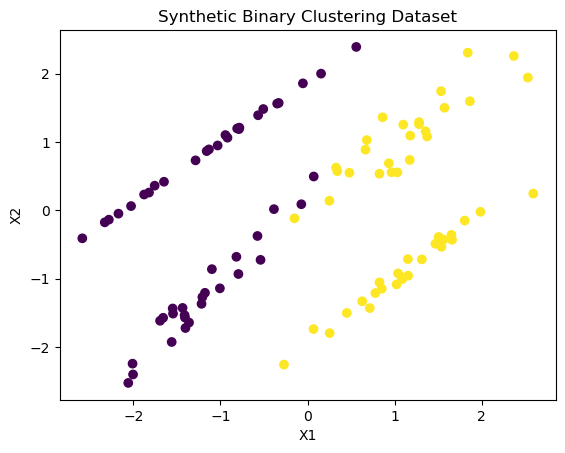

In [4]:
# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Synthetic Binary Clustering Dataset")
plt.show()

In [5]:
# Initialize parameters w and b
n_samples, n_features = X.shape
w = np.zeros(n_features)
b = 0

In [6]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [7]:
# Estimate y_hat using the sigmoid function (forward pass)
y_hat = sigmoid(np.dot(X, w) + b)

In [8]:
print("Shape of y_hat:", y_hat.shape)
print("Shape of X:", X.shape)
print("Shape of w:", w.shape)
print("Shape of y", y.shape)
print("Shape of y_hat - y.squeeze():", (y_hat - y.squeeze()).shape)

Shape of y_hat: (100,)
Shape of X: (100, 2)
Shape of w: (2,)
Shape of y (100,)
Shape of y_hat - y.squeeze(): (100,)


In [9]:
# Compute the predicted class labels using a threshold of 0.5
y_pred = (y_hat >= 0.5).astype(int)
print("Shape of y_pred:", y_pred.shape)
print("Predicted labels:\n", y_pred)

Shape of y_pred: (100,)
Predicted labels:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


Out of 100 predictions of 1, this is exactly what we'd expect. 

w=0 and b=0, so z=0 everywhere, and σ(0)=0.5 exactly. All points fall exactly on the threshold, and >= 0.5 classifies them all as 1. 

In [10]:
# Gradients (for backward pass)
dL_dw = (1 / n_samples) * np.dot(X.T, (y_hat - y))
dL_db = (1 / n_samples) * np.sum(y_hat - y)

In [11]:
print("Gradient w.r.t w:", dL_dw)
print("Gradient w.r.t b:", dL_db)

Gradient w.r.t w: [-0.5696031  -0.06629539]
Gradient w.r.t b: 0.0


If initially w=0, b=0 then z=0.

So $\hat{y} = 0.5$ everywhere, and:

$$
\frac{\partial \mathcal{L}}{\partial w} = \frac{1}{n} X^T (\hat{y} - y) = \frac{1}{n} X^T (0.5 - y)
$$

For samples where **y=1**:

$(0.5−1)= −0.5 * (0.5 - 1) = -0.5$ → negative gradient → w will increase after the update. 

Logical, since the model underpredicts.

For samples where **y=0**:

$(0.5−0)=+0.5$ → positive gradient → w will decrease. 

Also logical.

The gradient points in the right direction from the very first step. That’s a good sign and what we expect to obtain.

In [12]:
# Compute the Binary Cross Entropy (BCE) loss
loss = -(1 / n_samples) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
print("Binary Cross Entropy Loss:", loss)

Binary Cross Entropy Loss: 0.6931471805599453


Why 0.693?

When $\hat{y} = 0.5$ everywhere:

$$
\mathcal{L} = -\frac{1}{n}\sum \left[ y \log(0.5) + (1 - y)\log(0.5) \right] = -\log(0.5) = \log(2) \approx 0.693
$$

This is the maximum loss for a 2-class model—equivalent to predicting at random. This is the expected starting point.

In [13]:
# Update step (Gradient descent)
learning_rate = 0.1
w -= learning_rate * dL_dw
b -= learning_rate * dL_db

In [14]:
print("w after update:", w)
print("b after update:", b)

w after update: [0.05696031 0.00662954]
b after update: 0.0


In [15]:
# Recompute y_hat after the update
y_hat = sigmoid(np.dot(X, w) + b)

In [16]:
# Recompute the predicted class labels using a threshold of 0.5
y_pred = (y_hat >= 0.5).astype(int)
print("Shape of y_pred:", y_pred.shape)
print("New predicted labels:\n", y_pred)

Shape of y_pred: (100,)
New predicted labels:
 [1 1 0 0 1 0 0 1 0 1 1 1 0 1 1 0 1 0 1 0 1 0 0 0 1 0 1 1 1 1 1 0 0 0 1 1 0
 0 0 0 1 1 0 1 1 0 1 0 1 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 0 1 0 0 0 1 1 0 0 1
 1 0 1 1 0 0 0 1 1 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 0 0]


In [17]:
# Recompute the BCE loss after one step of gradient descent
loss_after_update = -(1 / n_samples) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
print("Binary Cross Entropy Loss after update:", loss_after_update)

Binary Cross Entropy Loss after update: 0.6610299351312448


The loss has dropped from 0.6931 to 0.6899. It has definitely decreased. The gradient is pointing in the right direction.

Also, the bias hasn't changed. It's still zero.

With $\hat{y} = 0.5$ everywhere and a perfectly balanced dataset (50 samples of class 0, 50 samples of class 1):

$$
\sum (\hat{y} - y) = \sum (0.5 - y) = 50 \times (0.5 - 0) + 50 \times (0.5 - 1) = 25 - 25 = 0
$$

This is a property of the balanced dataset in the first step—not a bug.  
As soon as $w$ changes and $\hat{y}$ is no longer uniformly distributed at $0.5$, $b$ will begin to update.

In [18]:
# Training loop
learning_rate = 0.1
n_iterations = 1000
loss_history = []

for _ in range(n_iterations):
    # Forward pass
    y_hat = sigmoid(np.dot(X, w) + b)
    
    # Compute loss
    bce_loss = -(1 / n_samples) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    # Backward pass
    dL_dw = (1/n_samples) * np.dot(X.T, (y_hat - y))
    dL_db = (1/n_samples) * np.sum(y_hat - y)

    # Update parameters
    w -= learning_rate * dL_dw
    b -= learning_rate * dL_db

    # Store loss history
    loss_history.append(bce_loss)

In [19]:
# Final parameters and loss
print("Final w:", w)
print("Final b:", b)

y_hat = sigmoid(np.dot(X, w) + b)
final_bce_loss = -(1 / n_samples) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
print("Final BCE Loss:", final_bce_loss)

Final w: [ 4.5033462  -1.30395116]
Final b: 0.09145012367359602
Final BCE Loss: 0.060144063680161515


The loss went from 0.661 to 0.0581. The model learned well. And the bias b finally moved as expected.

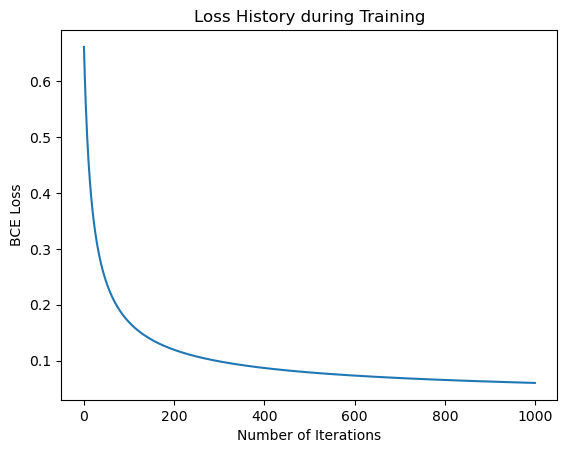

In [20]:
# Visualize the loss history
plt.plot(loss_history)
plt.xlabel("Number of Iterations")
plt.ylabel("BCE Loss")
plt.title("Loss History during Training")
plt.show()

In [21]:
# Compute the predicted class labels using a threshold of 0.5
y_pred = (y_hat >= 0.5).astype(int)
print("Shape of y_pred:", y_pred.shape)
print("New predicted labels:\n", y_pred)

Shape of y_pred: (100,)
New predicted labels:
 [0 1 0 0 1 0 1 1 0 1 1 0 0 1 1 0 1 0 1 0 1 0 0 0 1 0 1 1 1 1 0 0 0 0 1 1 0
 0 0 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 0 1 0 0 0 1 1 0 0 1
 1 0 1 1 0 0 0 1 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 0 0]


In [22]:
# Evaluation metrics
print("Accuracy:", accuracy_score(y, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))
print("Classification Report:\n", classification_report(y, y_pred))

Accuracy: 0.99
Confusion Matrix:
 [[50  0]
 [ 1 49]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.98      0.99        50

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



99% accuracy, with only 1 misclassified sample. The model performed very well on this synthetic dataset.

Considering the confusion matrix:

50 true negatives, 49 true positives

0 false positives, 1 false negative

The only misclassified sample is a class 1 sample predicted as 0, likely a point close to the decision boundary.

In [23]:
# Compute the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = sigmoid(np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b)
Z = Z.reshape(xx.shape)

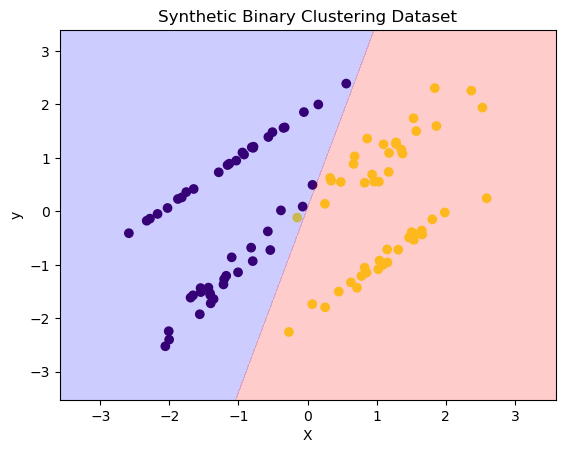

In [24]:
# Visualize the decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, colors=['blue', 'red'])
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Binary Clustering Dataset")
plt.show()

The only misclassified sample is visible. The yellow dot just to the left of the boundary at: x1 ≈ −0.5, x2 ≈ 0.5.